## はじめに

このノートでは、時系列データ分析で仮定する「弱定常」の共分散の仮定について、可視化を通じて理解を深めていくことを目的としている。そのため、定常性を検定する拡張Dickey-Fuller検定（ADF検定）などには触れない。

In [ ]:
from datetime import datetime
print("作成日時:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

作成日時: 2025-11-29 03:15:59


### 弱定常(weakly stationary)の仮定

弱定常の仮定は下記の通り3つある。参考書によっては2つの場合もあるが、ここではこの仮定で進める。
時系列 $\{Y_t\}$ が弱定常であるとは、以下の3つの条件を満たすことである：

$$
\begin{aligned}
&\qquad\ \mathbb{E}[Y_t] = \mu \\[6pt]
&\qquad\ \text{Var}(Y_t) = \mathbb{E}[(Y_t - \mu)^2] = \sigma^2 \\[6pt]
&\qquad\ \text{Cov}(Y_t, Y_{t+h}) = \mathbb{E}[(Y_t - \mu)(Y_{t+h} - \mu)] = \gamma(h) 
\quad \text{（}h\text{のみに依存し、}t\text{には依存しない）}
\end{aligned}
$$

ここで、3つ目の共分散の仮定の$h$はラグ（時間差）を表す。$h$のみに依存し、$t$には依存しない、つまり、自己共分散は時間差$h$のみに依存する。この3つ目の仮定が直感的に理解しづらい。時系列の異なる時点間の関係性が時間シフトに対して不変となる、という感じで説明されたり、そもそも見たらわかるでしょう程度にしか紹介されない。ここでは、可視化を通じて理解を深めたい。まずは共分散のおさらいから始める。

### 共分散(Covariance)

2つの変数$X$と$Y$があるとき、共分散は$X$と$Y$の連動性を表す。共分散がプラスの値であれば、片方が増えればもう片方も増える、マイナスの値であれば、片方が増えればもう片方は減る。共分散がゼロであればお互いに関係ない状態と判断できる。

$$Cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

### 自己共分散(AutoCovariance)

時系列の「自己」共分散時系列$y_t$における共分散は、「現時点($y_t$)」と「過去時点($y_{t-h}$)」との関係を見る。これを自己共分散 $\gamma(h)$ と呼ぶ。

$$\gamma(h) = Cov(y_t, y_{t-h}) = E[(y_t - \mu)(y_{t-h} - \mu)]$$

なぜ「時点差$h$にのみに依存すること」が重要なのか。もし、自己共分散が時点差$h$だけでなく、時点$t$にも依存しているとどうなるか。定常な世界であれば、「今日の$y_t$は、昨日の$y_{t-1}$に強く影響される」というルールは、1990年でも、2025年でも、2100年でも変わらない。「1日前$y_{t-1}$との関係性」という構造が一定だからこそ、過去のデータを使って未来を予測できる。

一方で非定常な世界（$t$に依存する場合）では、「1990年は昨日の影響を強く受けるが、2025年は昨日の影響を全く受けず、むしろ2日前の影響を受ける」というように、時点によって構造が変わってしまう状態とも言える。

「時間差$h$のみに依存する」ということは、「どんな時点$t$であっても、$h$時点前と現在との関係性というルールは変わらないと判断できる。感覚的には、$h=1$が強い正の共分散があれば、$X_{t}$が大きければ、$X_{t+1}$も大きくなる傾向が確率的に高いということ。次の時点は確率的に正の方にいきやすいが、ノイズ、外部要因などの影響で、確率的に必ず上に行くわけではない。他にも$h=10$が強い負の共分散があれば、現時点$X_{t}$が大きければ、確率的に$X_{t+1}$は小さくなりやすい。また、現時点$X_{t}$が小さければ、確率的に$X_{t+1}$は大きくなりやすいというイメージ。

### 可視化
ここからは可視化をしながらどのような場合に共分散の仮定が満たされているのか確認する。満たされるということは、時点差$h$のみに依存し、時点$t$には依存しないということ。まずは必要なライブラリと関数を定義しておく。

In [1]:
from typing import Any
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

n = 900
early = slice(0, 300)
middle = slice(300, 600)
late = slice(600, 900)
lags = range(1, 11)


def lag_pairs(series, lag=1):
    return series[:-lag], series[lag:]


def plot_time_series(Y, title):
    plt.figure(figsize=(10, 4))
    plt.plot(range(early.start, early.stop), Y[early], color='C0', label='Early')
    plt.plot(range(middle.start, middle.stop), Y[middle], color='C1', label='Middle')
    plt.plot(range(late.start, late.stop), Y[late], color='C2', label='Late')
    plt.title(title, fontsize=14)
    plt.xlabel("t")
    plt.ylabel("Y_t")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_lag_scatter(ax, lag, early_x, early_y, mid_x, mid_y, late_x, late_y):
    early_corr = np.corrcoef(early_x, early_y)[0, 1]
    mid_corr = np.corrcoef(mid_x, mid_y)[0, 1]
    late_corr = np.corrcoef(late_x, late_y)[0, 1]
    ax.scatter(early_x, early_y, label=f"Early (cov={early_corr:.2f})", alpha=0.5)
    ax.scatter(mid_x, mid_y, label=f"Middle (cov={mid_corr:.2f})", alpha=0.5)
    ax.scatter(late_x, late_y, label=f"Late (cov={late_corr:.2f})", alpha=0.5)
    ax.set_title(f"Lag {lag} (h={lag})", fontsize=13)
    ax.set_xlabel("Y_t")
    ax.set_ylabel(f"Y_(t+{lag})")
    ax.legend()
    ax.grid(True)

ここでは$t$の時点がわかりやすいように、系列を3つに区切って時点$t$を表現している。まずは正規分布から生成した弱定常な時系列データをみていく。

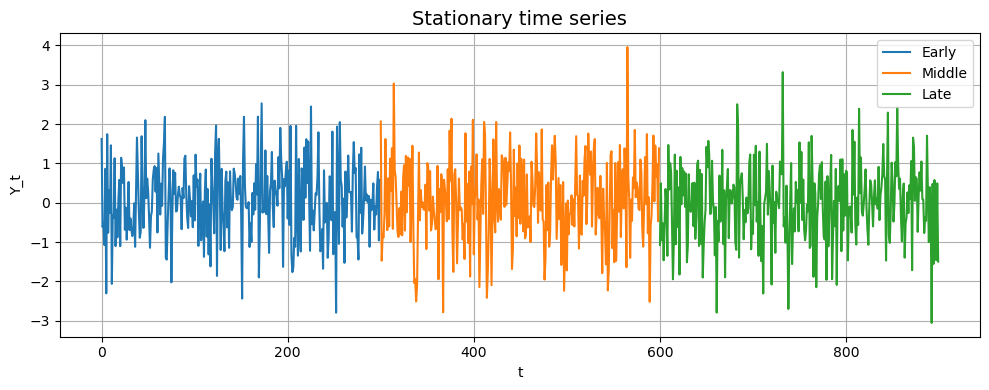

In [2]:
np.random.seed(1)
Y = np.random.randn(n)
plot_time_series(Y, title="Stationary time series")

3つ目の共分散の仮定が満たされているか、時点差$h$ごとに値の関係性を分析した散布図で確認する。この時系列データであれば、どの時点$t$でも共分散はほぼ同じなので、時点$t$に依存せず、時点差$h$に依存している状態とわかる。

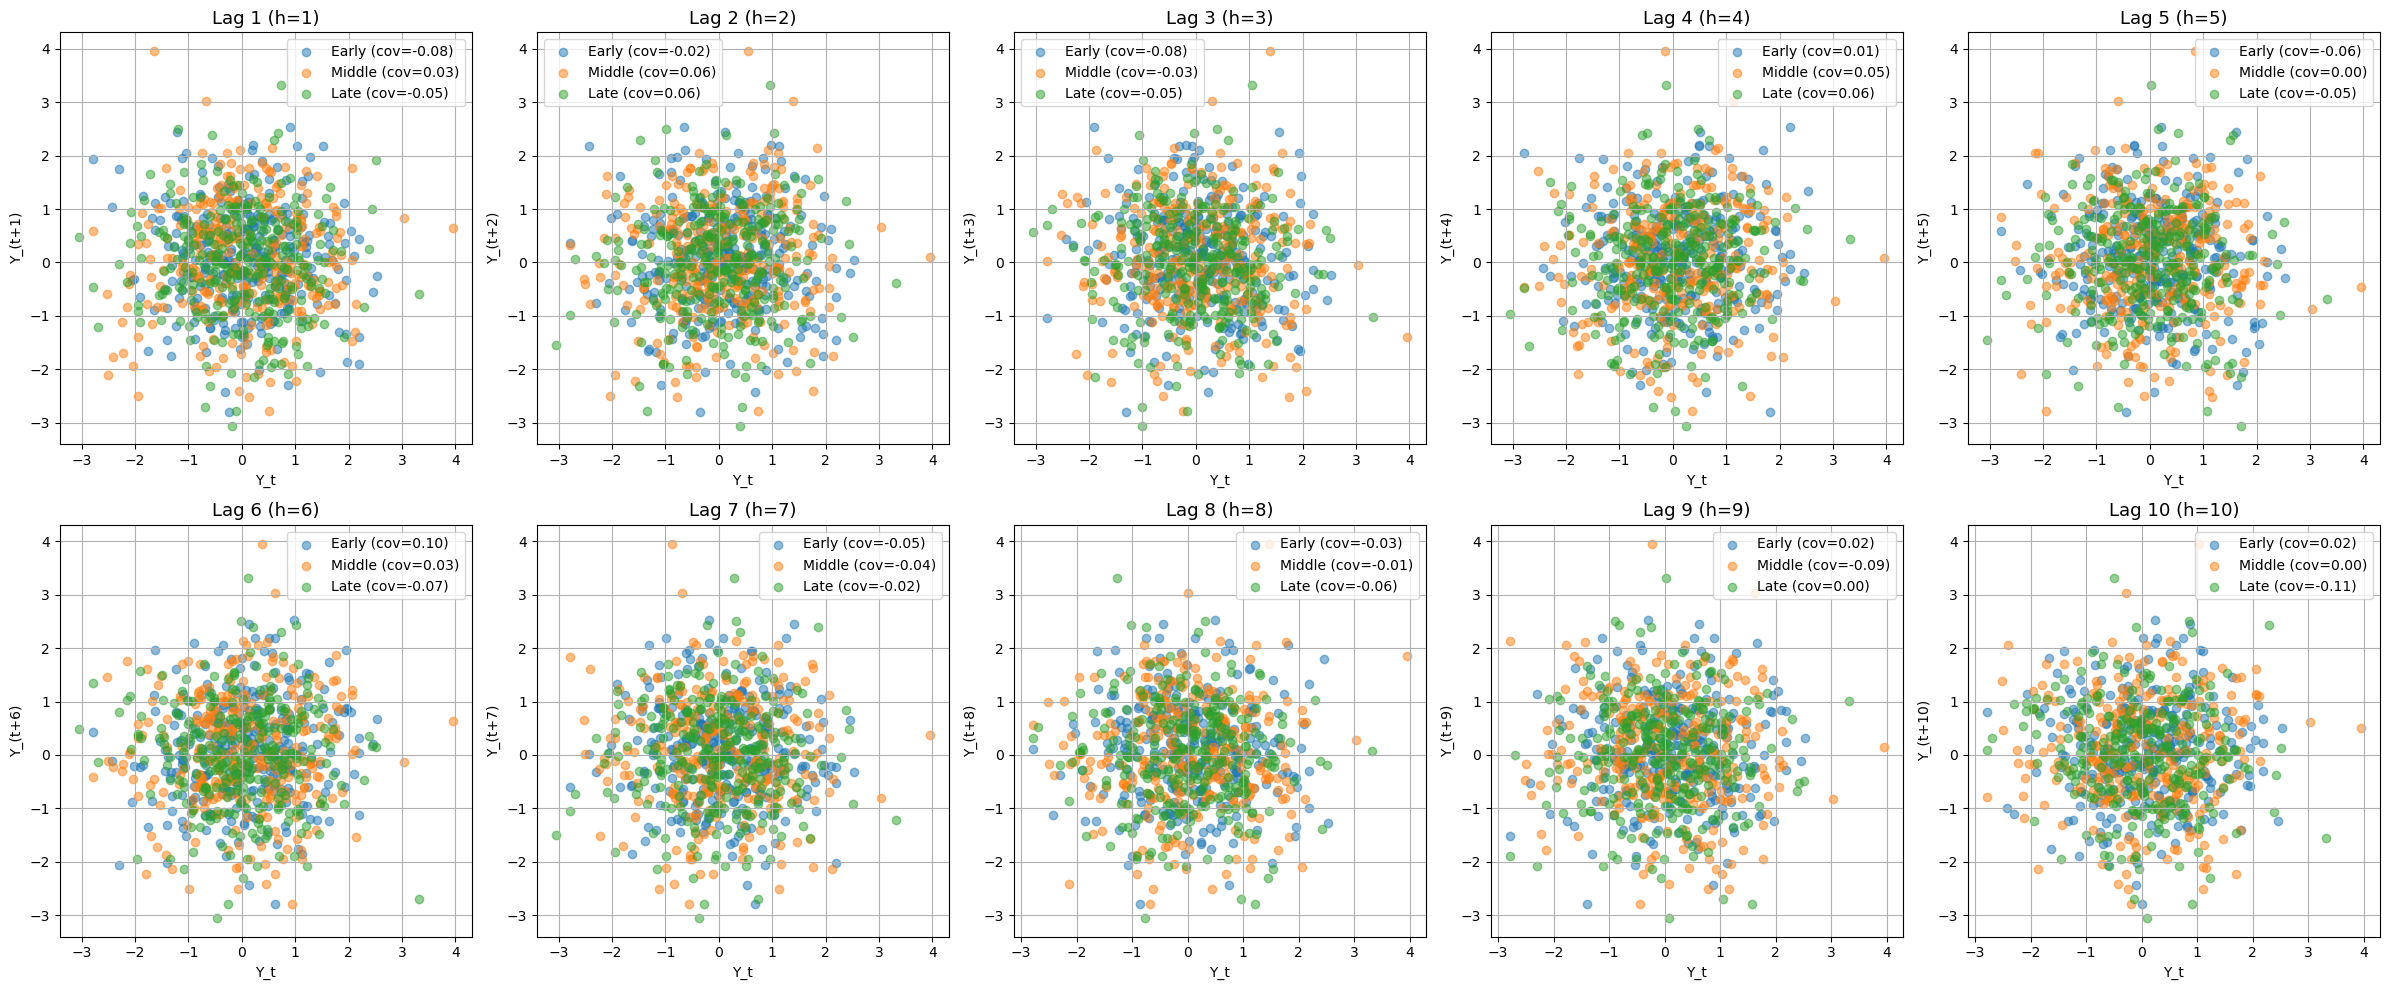

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for idx, lag in enumerate(lags):
    early_x, early_y = lag_pairs(Y[early], lag=lag)
    mid_x, mid_y = lag_pairs(Y[middle], lag=lag)
    late_x, late_y = lag_pairs(Y[late], lag=lag)

    plot_lag_scatter(axes[idx], lag, early_x, early_y, mid_x, mid_y, late_x, late_y)

plt.tight_layout()
plt.show()

次は定常っぽく見えて、実は非定常な時系列データをみていく。平均も分散も一定であるが、共分散の仮定を満たせてない。ただ、ADF検定もKPSS検定をしたりするとAR(1)過程なので、定常と判断される。おそらく。

|期間|時刻$t$|自己回帰係数$ϕ_{t}$​|構造の特徴（$Y_{t}​$ と $Y_{t-1}​$​ の関係）|
|:---:|:---:|:---:|:---:|
|Early|$t$=1∼300|$\phi$=0.8|強い正の相関（慣性が働き、前の値と同じ方向に動く）|
|Middle|$t$=301∼600|$\phi$=−0.8|強い負の相関（反転が起こり、前の値と反対方向に動く）|
|Late|$t$=601∼900|$\phi$=0.5|中程度の正の相関（慣性は残るが減衰が速くなる）|

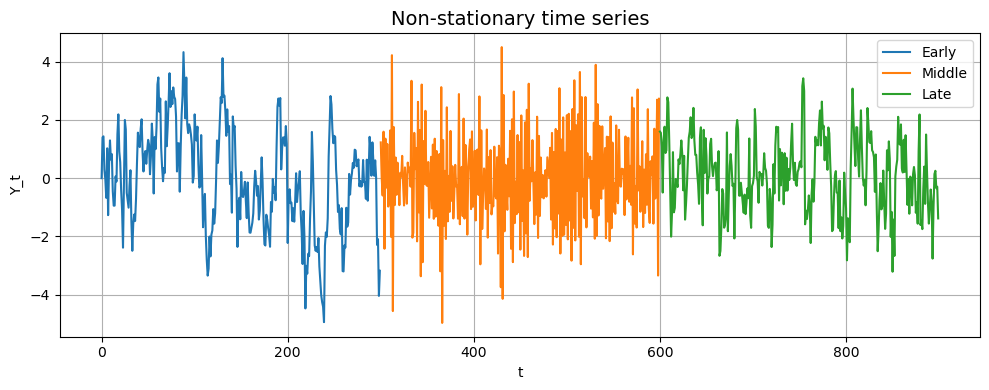

In [ ]:
np.random.seed(999)
phi_segments = np.zeros(n)
phi_segments[0:300] = 0.8
phi_segments[300:600] = -0.8
phi_segments[600:900] = 0.5

eps = np.random.randn(n)
Y = np.zeros(n)
for t in range(1, n):
    Y[t] = phi_segments[t] * Y[t-1] + eps[t]

plot_time_series(Y, "Non-stationary time series")

散布図を見ると、共分散が$t$に依存していることがわかる。$h=1$では、Early時点では正の共分散関係があり、Middle時点では負の共分散関係があり、Late時点では共分散なない。これは、時点$t$によって共分散が変化することを示しており、各時点で参考程度の計算している共分散も大きく異なる。

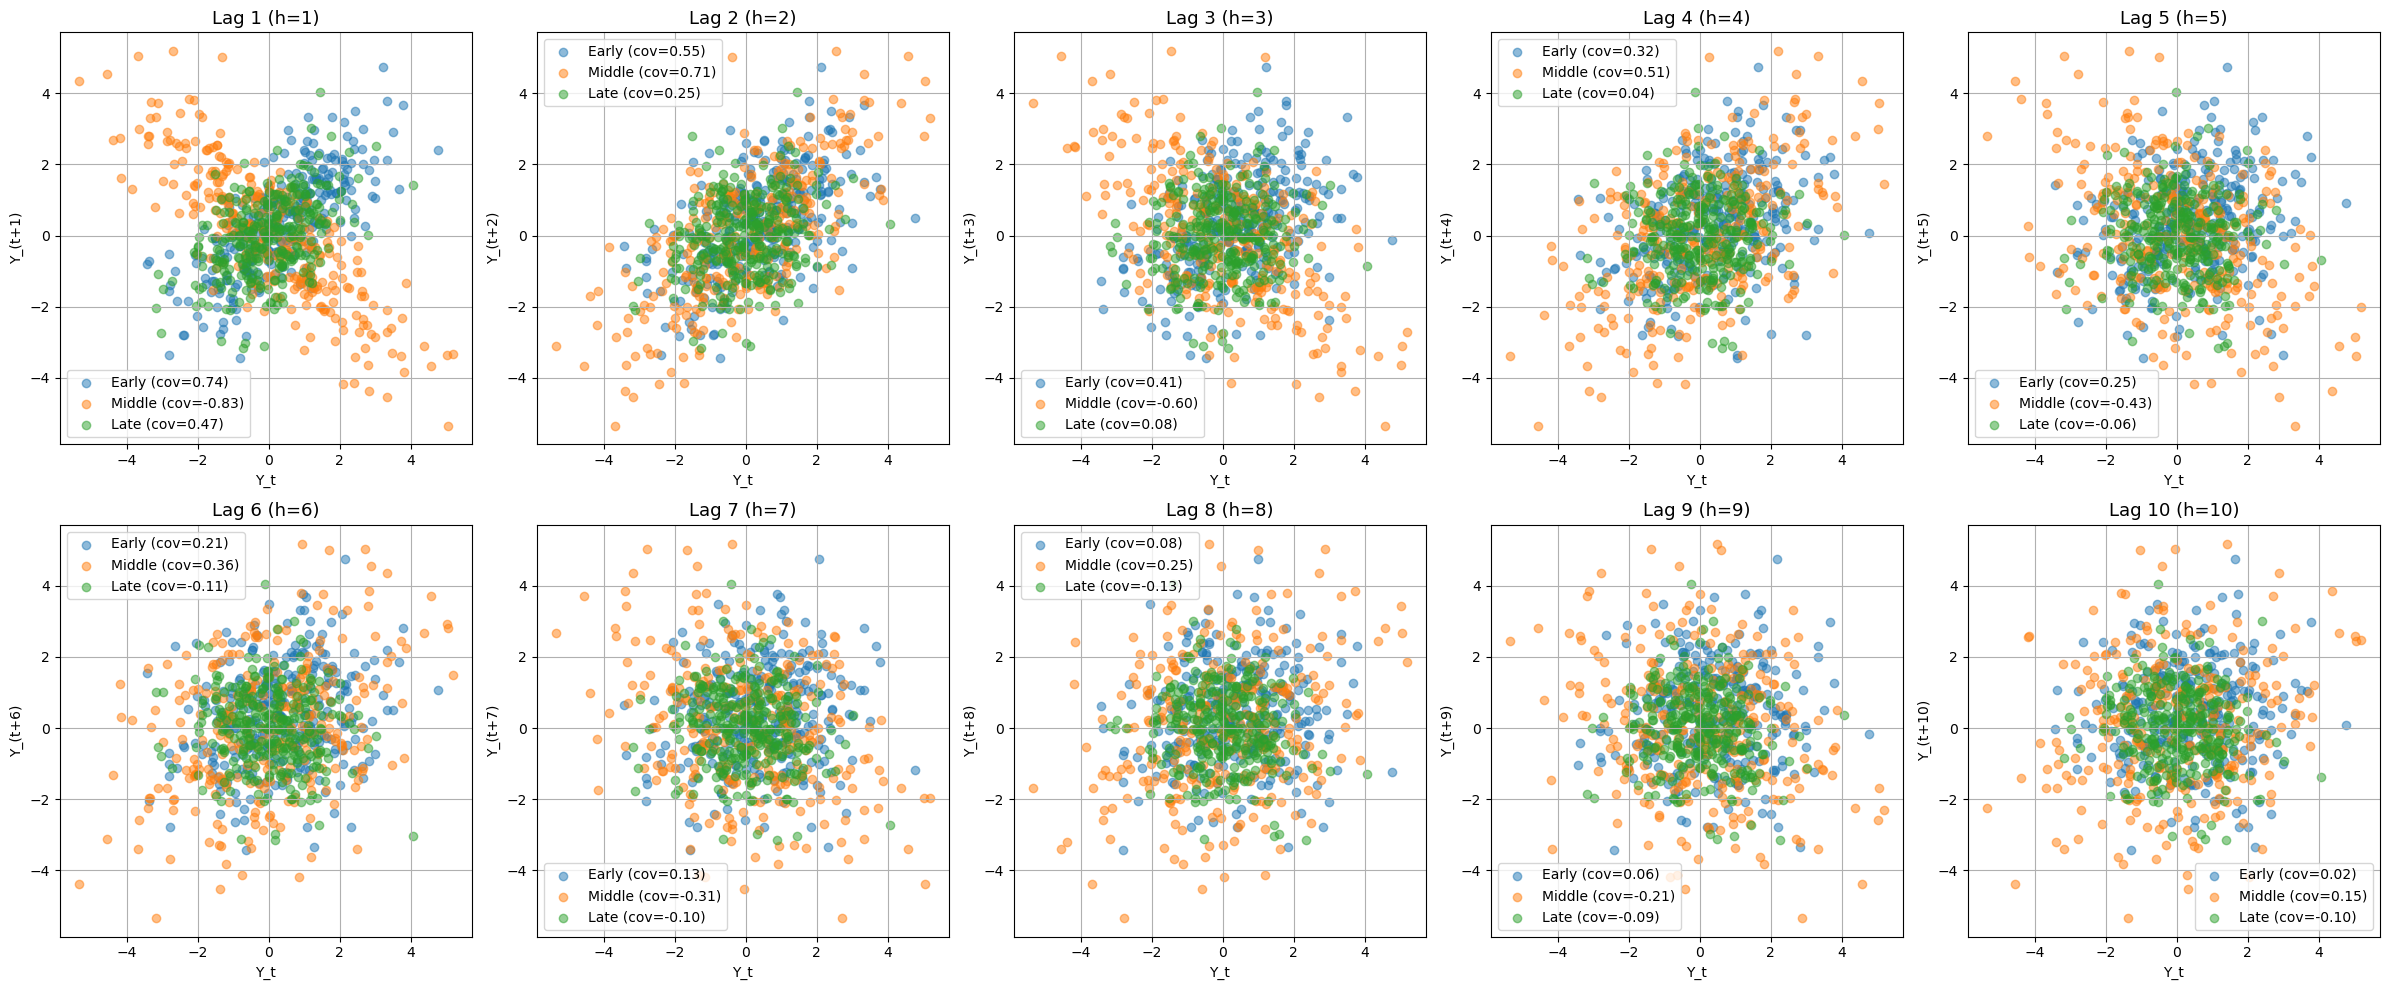

In [5]:
lags = range(1, 11)
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for idx, lag in enumerate(lags):
    early_x, early_y = lag_pairs(Y[early], lag=lag)
    mid_x, mid_y = lag_pairs(Y[middle], lag=lag)
    late_x, late_y = lag_pairs(Y[late], lag=lag)

    plot_lag_scatter(axes[idx], lag, early_x, early_y, mid_x, mid_y, late_x, late_y)


plt.tight_layout()
plt.show()

さきほどは意図的に仮定が破綻するようにしたが、通常のAR(1)過程をみていく。

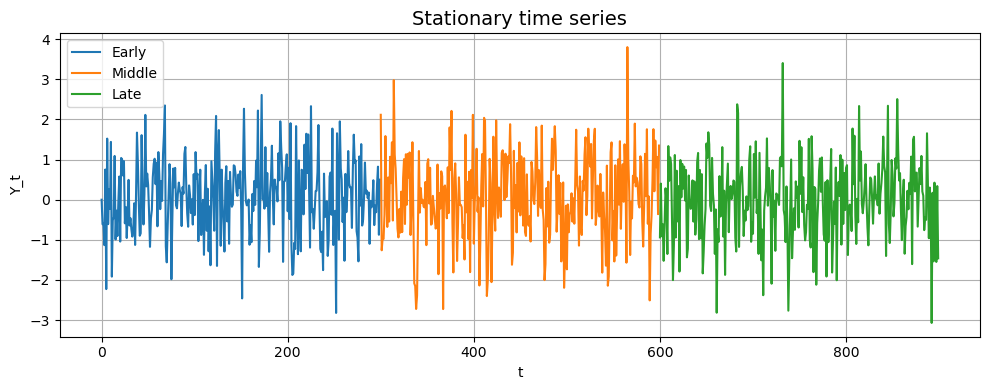

In [23]:
np.random.seed(1)
phi = 0.1
eps = np.random.randn(n)
Y = np.zeros(n)
for t in range(1, n):
    Y[t] = phi * Y[t-1] + eps[t]

plot_time_series(Y, title="Stationary time series")

共分散が$t$に依存していないことがわかる。どの$h$においても、Early時点、Middle時点、Late時点の共分散も同じである。

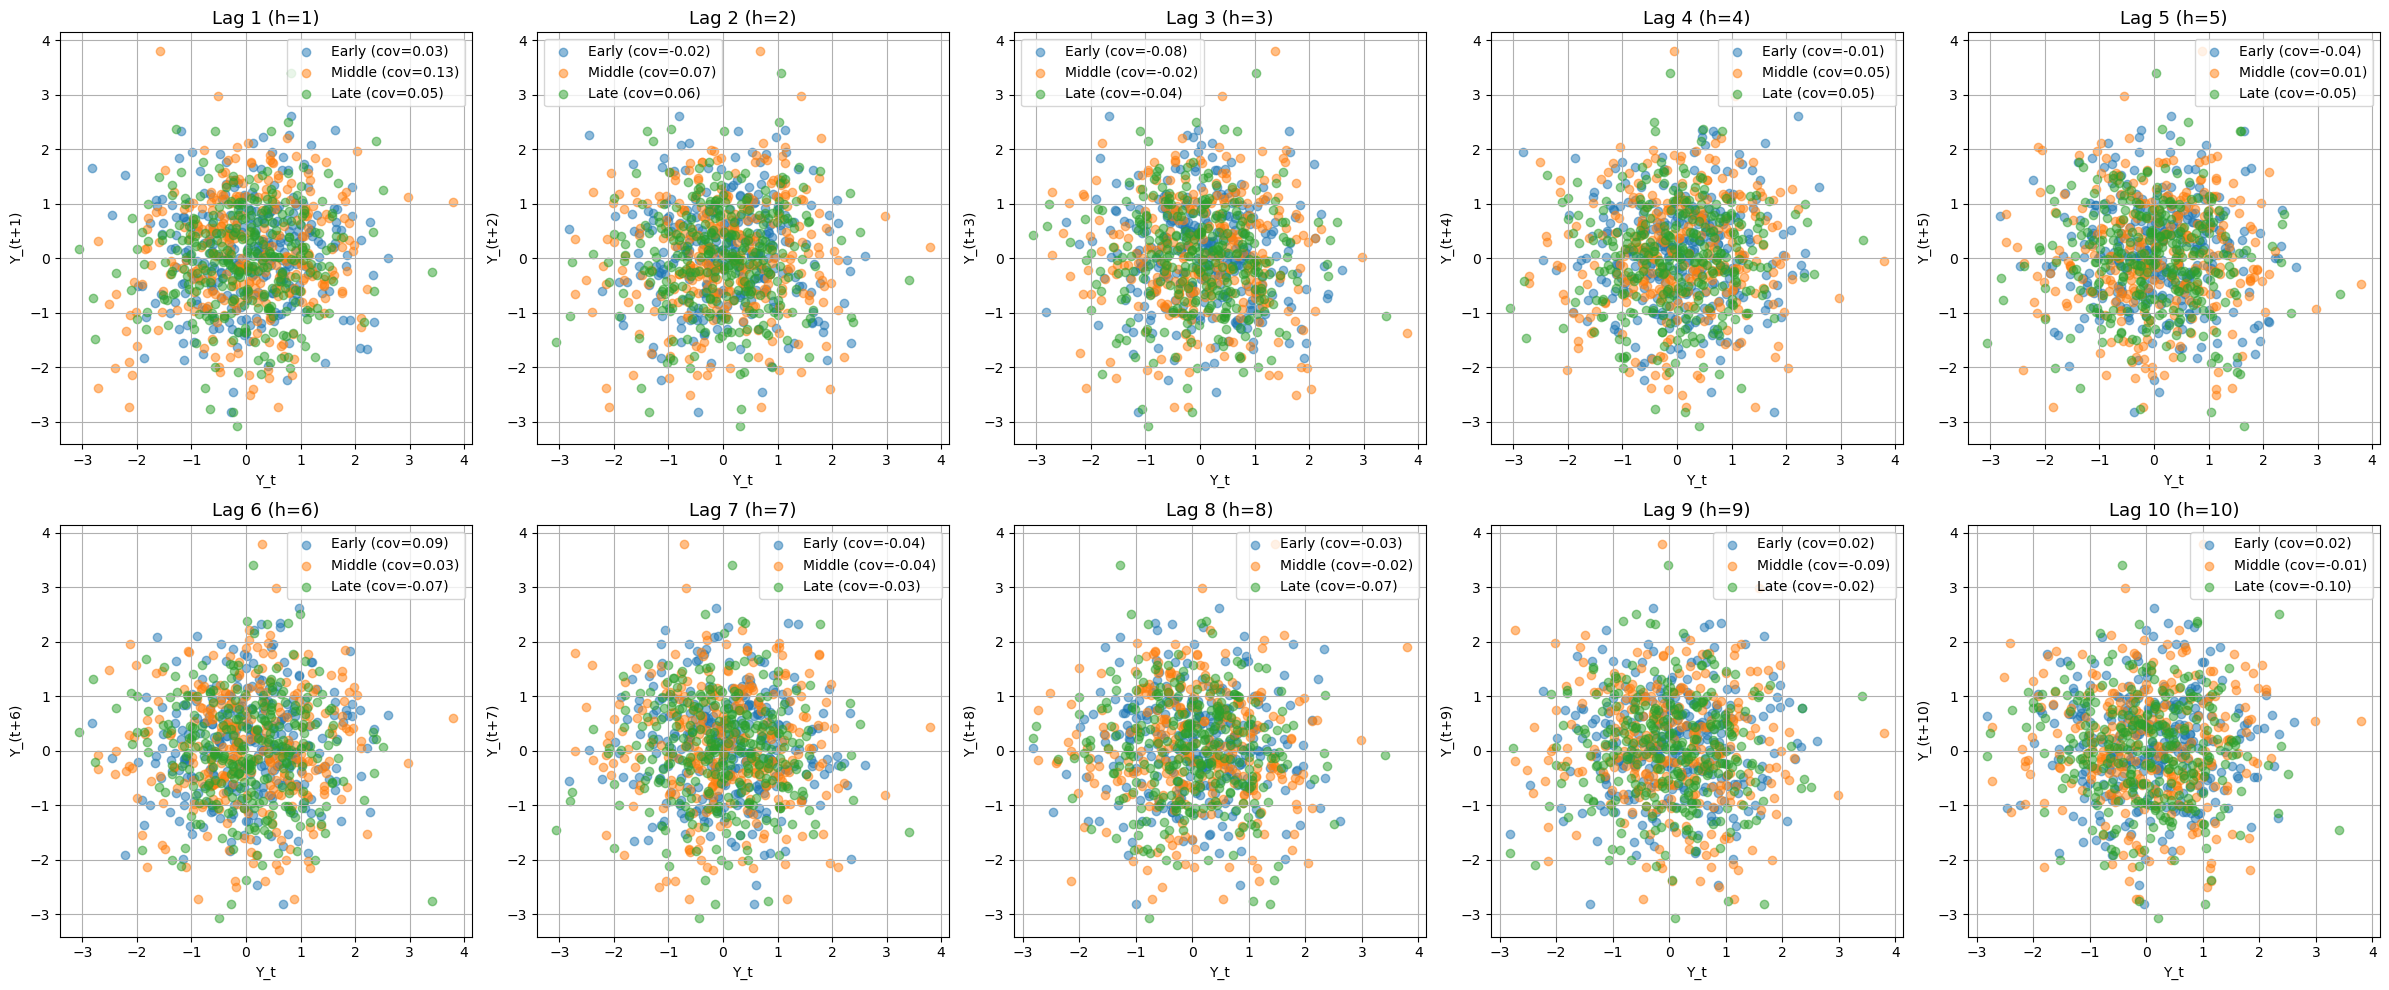

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for idx, lag in enumerate(lags):
    early_x, early_y = lag_pairs(Y[early], lag=lag)
    mid_x, mid_y = lag_pairs(Y[middle], lag=lag)
    late_x, late_y = lag_pairs(Y[late], lag=lag)

    plot_lag_scatter(axes[idx], lag, early_x, early_y, mid_x, mid_y, late_x, late_y)

plt.tight_layout()
plt.show()

最後に共分散の仮定は満たすが、平均の過程を満たせていない非定常なデータを確認する。

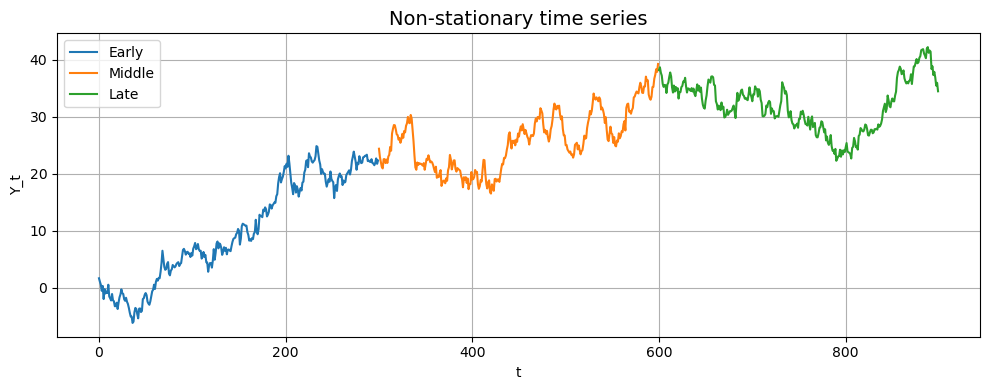

In [24]:
np.random.seed(1)
eps = np.random.randn(n)
Y = np.cumsum(eps)

plot_time_series(Y, "Non-stationary time series")

共分散が$t$に依存していないことがわかる。どの$h$においても、Early時点、Middle時点、Late時点の共分散もほとんど同じである。ただ、トレンドがあるので、これは弱定常とはいえない。

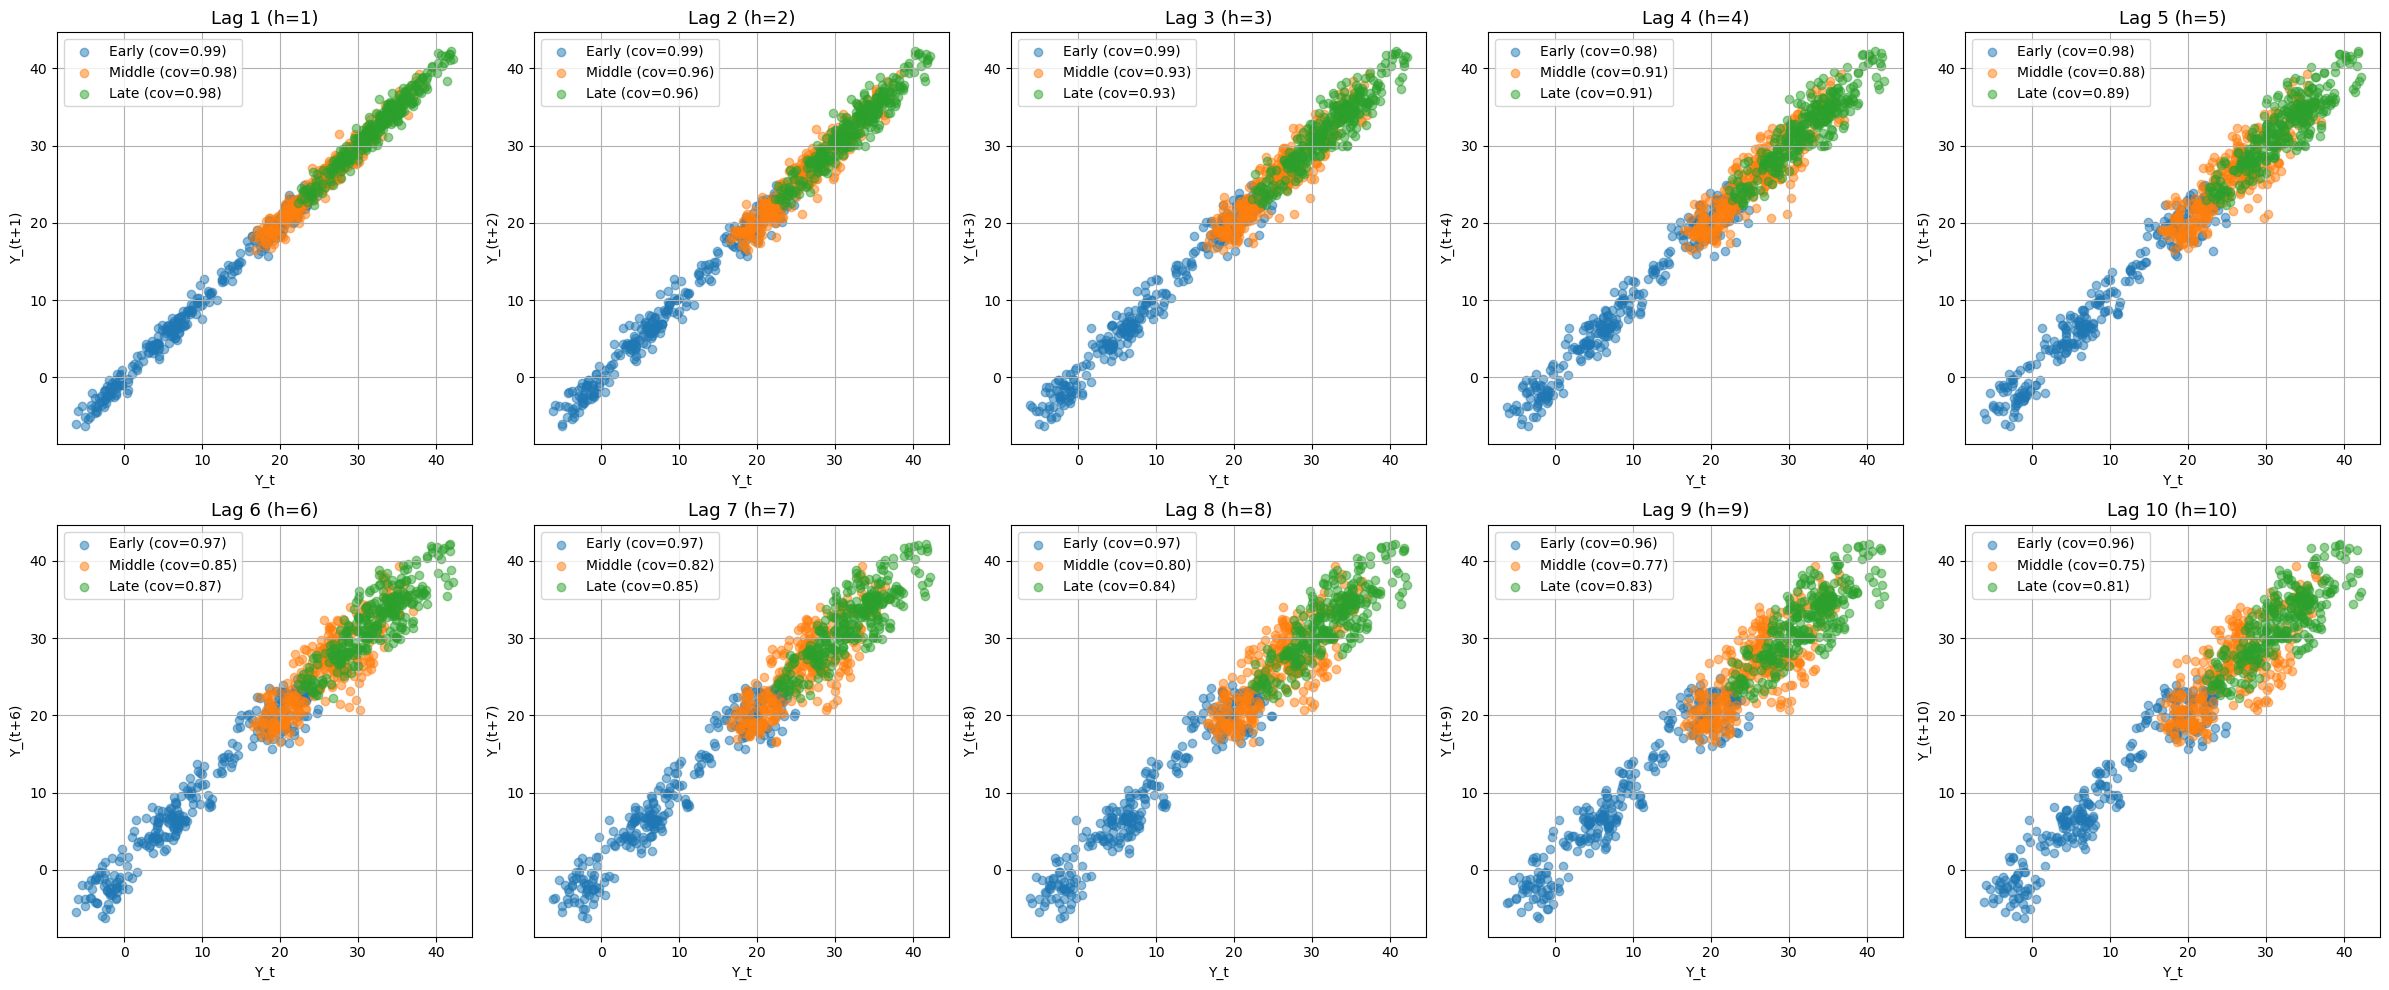

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for idx, lag in enumerate(lags):
    early_x, early_y = lag_pairs(Y[early], lag=lag)
    mid_x, mid_y = lag_pairs(Y[middle], lag=lag)
    late_x, late_y = lag_pairs(Y[late], lag=lag)

    plot_lag_scatter(axes[idx], lag, early_x, early_y, mid_x, mid_y, late_x, late_y)


plt.tight_layout()
plt.show()

### まとめ

- 共分散の定義:$E[(y_t - \mu)(y_{t-h} - \mu)]$ は、現時点のデータと過去時点のデータの関係性の「向き」や「強さ」を表す。
- 時点差$h$のみに依存する理由:データの生成ルールが「時間の経過によって変化しない」ことを保証するため。変化しないからパターンを捉えて将来予測できる。
  - 数値例の直感:平均と分散仮定を満たし、「昨日と今日の関係」が、100年前も現在も100年後も同じ共分散なのであれば、それは弱定常。
  - 時点によって関係式が変わるなら、それは非定常で未来を予測できない。